# Day 3 — Workforce Intelligence
### Enterprise HR AI — Workforce Intelligence & Upskilling Platform

## Project Overview

This is the part of the project the whole platform is really about: not just
predicting who might leave (Day 2), but understanding engagement, mapping what
each role actually requires, finding the gap between what an employee has and
what their role needs, and turning that gap into a concrete recommendation.

None of this needs a fancy model to start — it's mostly honest data work with
aggregation, set comparisons, and business rules. A smarter recommendation model
can always be added later; today's version is deliberately simple first.

**What this notebook does, in order:**

| Step | Section | What it answers |
|------|---------|------------------|
| 10 | Engagement Analytics | Where is engagement lowest, and who needs attention? |
| 11 | Role Intelligence | What does each role actually require, in one place? |
| 12 | Employee Skills | What skills does each employee currently have? |
| 13 | Skill Gap Engine | What's missing between an employee and their role? |
| 14 | Organization-Wide Skill Gap | Which missing skills are a company-wide problem? |
| 15 | Upskilling Recommendation Engine | What should each employee learn next? |
| 16 | Employee Intelligence Table | One row per employee, everything combined |


## 0. Setup

### 0.1 Importing Libraries

`pandas`/`numpy` for the data work, `matplotlib` for charts, `joblib` to load
Day 2's saved attrition model, and `scikit-learn`'s TF-IDF + cosine similarity for
the semantic-matching part of the recommendation engine (Section 15).

In [1]:
import os
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

### 0.2 Project Folder Structure

Reusing Day 1 and Day 2's folders, plus one new one: `data/external/`, for the
employee-skills table built in Section 12. It's kept separate from `data/processed/`
because it isn't derived from the original 5 raw files the way everything else is —
more on that in Section 12.1.

In [2]:
BASE = "."  # this notebook lives at the project root, next to Day 1 and Day 2
PROCESSED_PATH = f"{BASE}/data/processed"
EXTERNAL_PATH = f"{BASE}/data/external"
MODELS_PATH = f"{BASE}/models"

os.makedirs(EXTERNAL_PATH, exist_ok=True)

print("Processed files:", os.listdir(PROCESSED_PATH))
print("Model files:", os.listdir(MODELS_PATH))

Processed files: ['career_path_intelligence.csv', 'employee_attrition_processed.csv', 'employee_intelligence.csv', 'engagement_processed.csv', 'essential_skills_processed.csv', 'occupation_master.csv', 'org_skill_heatmap.csv', 'software_skills_processed.csv']
Model files: ['attrition_pipeline.joblib', 'v1', 'v2', 'v3']


### 0.3 Loading Day 1 + Day 2 Outputs

Everything today builds on cleaned Day 1 tables and the Day 2 attrition model —
nothing here touches the raw CSVs directly.

In [3]:
REQUIRED_FILES = [
    "employee_attrition_processed.csv", "engagement_processed.csv",
    "occupation_master.csv", "essential_skills_processed.csv",
    "software_skills_processed.csv",
]
missing = [f for f in REQUIRED_FILES if not os.path.exists(f"{PROCESSED_PATH}/{f}")]
assert not missing, f"Missing processed file(s): {missing}. Run Day 1 first."
assert os.path.exists(f"{MODELS_PATH}/attrition_pipeline.joblib"), \
    "Missing models/attrition_pipeline.joblib. Run Day 2 first."

attrition = pd.read_csv(f"{PROCESSED_PATH}/employee_attrition_processed.csv")
engagement = pd.read_csv(f"{PROCESSED_PATH}/engagement_processed.csv")
occupation = pd.read_csv(f"{PROCESSED_PATH}/occupation_master.csv")
essential_skills = pd.read_csv(f"{PROCESSED_PATH}/essential_skills_processed.csv")
software_skills = pd.read_csv(f"{PROCESSED_PATH}/software_skills_processed.csv")
attrition_pipeline = joblib.load(f"{MODELS_PATH}/attrition_pipeline.joblib")

print(f"Employees: {attrition.shape[0]}")
print(f"Roles: {occupation.shape[0]}")
print(f"Loaded model: {type(attrition_pipeline.named_steps['model']).__name__}")

Employees: 600
Roles: 7
Loaded model: RandomForestClassifier


---

## 10. Engagement Analytics

No ML here yet — just aggregation. The goal is simple: where is engagement lowest,
broken down in ways HR can actually act on, and who specifically needs a closer
look. If a meaningful target to predict shows up later, this could be revisited
with regression or a KMeans-based segmentation — not needed for the MVP.

### 10.1 Company-Wide Average

In [4]:
performance_df = attrition.merge(engagement, on="EmployeeID", how="left", validate="one_to_one")

overall_avg_engagement = performance_df["EngagementScore"].mean()
print(f"Company-wide average engagement: {overall_avg_engagement:.1f} / 100")

Company-wide average engagement: 68.8 / 100


### 10.2 Engagement by Department

Sorted ascending, so the department needing the most attention is first.

Department
Human Resources           68.1
IT                        68.3
Sales                     68.6
Research & Development    69.9
Name: EngagementScore, dtype: float64


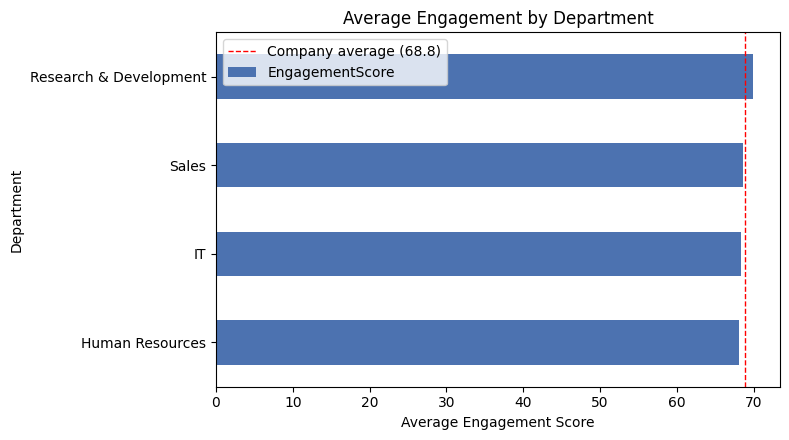

In [5]:
engagement_by_dept = (
    performance_df.groupby("Department")["EngagementScore"].mean().sort_values()
)
print(engagement_by_dept.round(1))

fig, ax = plt.subplots(figsize=(8, 4.5))
engagement_by_dept.plot(kind="barh", ax=ax, color="#4C72B0")
ax.axvline(overall_avg_engagement, color="red", linestyle="--", linewidth=1,
           label=f"Company average ({overall_avg_engagement:.1f})")
ax.set_xlabel("Average Engagement Score")
ax.set_title("Average Engagement by Department")
ax.legend()
plt.tight_layout()
plt.show()

### 10.3 Lowest-Engagement Employees

A direct list HR can look at, not just an aggregate number — the 15 employees with
the lowest engagement scores, alongside their department and role for context.

In [6]:
lowest_engagement = (
    performance_df.sort_values("EngagementScore")
    [["EmployeeID", "Department", "JobRole", "EngagementScore", "PerformanceRating"]]
    .head(15)
    .reset_index(drop=True)
)
lowest_engagement

,EmployeeID,Department,JobRole,EngagementScore,PerformanceRating
0,577,IT,ML Engineer,0,4.0
1,465,Human Resources,MLOps Engineer,24,2.0
2,19,IT,Data Analyst,27,2.0
3,65,IT,ML Engineer,29,1.0
4,413,Research & Development,Sales Executive,30,2.0
5,570,IT,Sales Executive,31,3.0
6,332,Sales,Research Scientist,31,3.0
7,433,Research & Development,HR Executive,31,2.0
8,384,IT,HR Executive,34,1.0
9,543,Sales,ML Engineer,34,4.0


### 10.4 What's Next for Engagement

No target to predict yet, so no model is built here. If the project later defines
one (e.g. "will this employee's engagement drop next quarter"), this is where a
regression model would go — or, without a specific target, a KMeans segmentation
could still group employees into engagement profiles for a more nuanced view than
one company-wide average.

---

## 11. Role Intelligence

`occupation_data.csv` becomes the **role master table** here — no ML, it's
reference data. The point is to remove ambiguity: every role gets one clean ID and
name, so later on it's possible to say "ML Engineer requires Python, MLOps, Docker,
AWS" without any doubt about which role, or which skill list, is meant.

### 11.1 Combining Essential + Software Skills

Day 1 flagged that `essential_skills.csv` and `software_skills.csv` are really two
halves of the same idea — what a role needs. They're combined here into one unified
`role_skills` table, tagged with a `SkillType` column so the distinction isn't lost,
just no longer split across two files.

In [7]:
essential_tagged = essential_skills.assign(SkillType="Essential").rename(columns={"Skill": "SkillName"})
software_tagged = software_skills.assign(SkillType="Software").rename(columns={"SoftwareSkill": "SkillName"})

required_skills = pd.concat([essential_tagged, software_tagged], ignore_index=True)
role_skills = required_skills.merge(occupation, on="OccupationID", how="left")

print(f"Combined required-skills table: {role_skills.shape[0]} rows "
      f"({len(essential_tagged)} essential + {len(software_tagged)} software)")
role_skills.head(10)

Combined required-skills table: 44 rows (25 essential + 19 software)


,OccupationID,SkillName,Importance,SkillType,RoleName,Department
0,1,Negotiation,High,Essential,Sales Executive,Sales
1,1,CRM Tools,Medium,Essential,Sales Executive,Sales
2,1,Communication,Medium,Essential,Sales Executive,Sales
3,2,SQL,Medium,Essential,Data Analyst,Research & Development
4,2,Excel,High,Essential,Data Analyst,Research & Development
5,2,Statistics,High,Essential,Data Analyst,Research & Development
6,2,Data Visualization,Medium,Essential,Data Analyst,Research & Development
7,3,Python,Medium,Essential,ML Engineer,Research & Development
8,3,Machine Learning,Medium,Essential,ML Engineer,Research & Development
9,3,MLOps,Medium,Essential,ML Engineer,Research & Development


### 11.2 The Role Master — One Row Per Role, Full Skill List

For quick lookups later (Sections 13–16), `role_required_map` turns this into a
dictionary: role name → the full set of skills that role requires, essential and
software combined.

In [8]:
role_required_map = role_skills.groupby("RoleName")["SkillName"].apply(set).to_dict()

role_master = occupation.copy()
role_master["RequiredSkillCount"] = role_master["RoleName"].map(
    lambda r: len(role_required_map.get(r, set()))
)
role_master["RequiredSkills"] = role_master["RoleName"].map(
    lambda r: ", ".join(sorted(role_required_map.get(r, set())))
)
role_master

,OccupationID,RoleName,Department,RequiredSkillCount,RequiredSkills
0,1,Sales Executive,Sales,5,"CRM Tools, Communication, Excel, Negotiation, ..."
1,2,Data Analyst,Research & Development,5,"Data Visualization, Excel, SQL, Statistics, Ta..."
2,3,ML Engineer,Research & Development,7,"AWS, Docker, MLOps, Machine Learning, PyTorch,..."
3,4,HR Executive,Human Resources,5,"Communication, Conflict Resolution, Excel, HR ..."
4,5,Research Scientist,Research & Development,4,"AWS, Python, Research Methods, Statistics"
5,6,Software Engineer,IT,6,"AWS, Docker, Java, Kubernetes, Python, System ..."
6,7,MLOps Engineer,IT,7,"AWS, CI/CD, Cloud, Docker, Kubernetes, MLOps, ..."


### 11.3 Importance Lookup

One more lookup built here, reused by the skill gap engine below: `(role, skill) ->
importance` ("High"/"Medium"), so a missing *High*-importance skill can be weighted
more heavily than a missing *Medium* one.

In [9]:
skill_importance_lookup = role_skills.set_index(["RoleName", "SkillName"])["Importance"].to_dict()

# quick check
sample_role = role_master["RoleName"].iloc[0]
print(f"Sample lookup -- {sample_role}:")
for skill in sorted(role_required_map[sample_role]):
    print(f"  {skill}: {skill_importance_lookup.get((sample_role, skill))}")

Sample lookup -- Sales Executive:
  CRM Tools: Medium
  Communication: Medium
  Excel: Medium
  Negotiation: High
  Salesforce: High


---

## 12. Employee Skills Table

### 12.1 The Honest Catch

Here's the thing worth checking for honestly before going further: **none of the
five raw datasets record what skills each employee currently has** — only what
skills each *role* requires. Without that, a real skill-gap calculation is
impossible; it would just be comparing role requirements to nothing.

Two options, per the project notes:
- If employee skill data already exists somewhere → use it directly.
- If it doesn't → build a controlled table for the MVP so the rest of the pipeline
  has something real to work with.

It doesn't exist here, so the second path is the one taken below. This is why the
result is saved to `data/external/`, not `data/processed/` — it isn't a cleaned
version of one of the original 5 files, it's a new, clearly-labelled synthetic
input, kept separate so nobody mistakes it for real HRIS data later.

### 12.2 Building the Table

Each employee's current skills are generated relative to what their *own role*
actually requires (an ML Engineer is far more likely to already know Python than
Terraform), with longer-tenured employees more likely to have picked up more of
their role's skills over time — a small, defensible assumption, not a random guess.
A small chance of one extra general skill (`Communication`/`Excel`) reflects that
employees pick up things outside their core role too. Format matches the project's
target shape: `employee_id, current_skill`, one row per (employee, skill) pair.

Only generated if the file doesn't already exist — same idiom as Day 1's raw-data
generator, so re-running this notebook doesn't silently regenerate a different
random skill set each time.

In [10]:
def generate_employee_skills(attrition_df, role_map, seed=RANDOM_STATE):
    """Builds a synthetic 'what skills does this employee already have' table.
    Probability of already having a given required skill increases with tenure;
    a small chance of one extra general skill is added on top.
    """
    gen = np.random.default_rng(seed)
    rows = []
    for _, emp in attrition_df.iterrows():
        required = role_map.get(emp["JobRole"], set())
        tenure_factor = min(emp["YearsAtCompany"] / 10, 1.0)
        acquisition_prob = 0.62 + 0.30 * tenure_factor

        for skill in required:
            if gen.random() < acquisition_prob:
                rows.append({"employee_id": emp["EmployeeID"], "current_skill": skill})

        if gen.random() < 0.15:
            rows.append({
                "employee_id": emp["EmployeeID"],
                "current_skill": gen.choice(["Communication", "Excel"]),
            })

    return pd.DataFrame(rows).drop_duplicates()


skills_path = f"{EXTERNAL_PATH}/employee_skills.csv"
if not os.path.exists(skills_path):
    employee_skills = generate_employee_skills(attrition, role_required_map)
    employee_skills.to_csv(skills_path, index=False)
    print(f"Generated synthetic employee_skills.csv ({len(employee_skills)} rows) -- real file not found.")
else:
    employee_skills = pd.read_csv(skills_path)
    print(f"Loaded existing employee_skills.csv ({len(employee_skills)} rows).")

employee_skills.head(10)

Loaded existing employee_skills.csv (2469 rows).


,employee_id,current_skill
0,1,Salesforce
1,1,CRM Tools
2,2,AWS
3,2,Python
4,2,Research Methods
5,2,Statistics
6,3,Python
7,3,AWS
8,3,Kubernetes
9,3,Docker


### 12.3 Employee Skill Lookup

Same pattern as Section 11.2 — a dictionary for fast lookups: employee ID → the
set of skills they currently have.

In [11]:
employee_skill_map = employee_skills.groupby("employee_id")["current_skill"].apply(set).to_dict()

n_with_skills = len(employee_skill_map)
avg_skills = employee_skills.groupby("employee_id").size().mean()
print(f"Employees with at least one recorded skill: {n_with_skills} / {len(attrition)}")
print(f"Average skills recorded per employee: {avg_skills:.1f}")

Employees with at least one recorded skill: 596 / 600
Average skills recorded per employee: 4.1


---

## 13. Skill Gap Engine

The core logic is just set subtraction — required skills minus what the employee
already has:

```python
required = {'Python', 'SQL', 'MLOps', 'Docker', 'AWS'}   # ML Engineer
has = {'Python', 'SQL', 'AWS'}                            # one employee
gap = required - has                                      # {'MLOps', 'Docker'}
```

That's it — Python set operations, plus a bit of pandas, plus the importance
weighting built in Section 11.3, so a missing *High*-importance skill counts for
more than a missing *Medium* one in the severity score. No model required for this
part.

### 13.1 Computing the Gap for Every Employee

In [12]:
IMPORTANCE_WEIGHT = {"High": 2, "Medium": 1}

def compute_skill_gap(employee_id, role, role_map, skill_map, importance_lookup):
    required = role_map.get(role, set())
    has = skill_map.get(employee_id, set())
    gap = required - has
    severity_score = sum(
        IMPORTANCE_WEIGHT.get(importance_lookup.get((role, s), "Medium"), 1) for s in gap
    )
    return required, has, gap, severity_score


gap_rows = []
for _, emp in attrition.iterrows():
    required, has, gap, severity_score = compute_skill_gap(
        emp["EmployeeID"], emp["JobRole"], role_required_map,
        employee_skill_map, skill_importance_lookup,
    )
    gap_rows.append({
        "EmployeeID": emp["EmployeeID"],
        "JobRole": emp["JobRole"],
        "RequiredCount": len(required),
        "HasCount": len(has & required),
        "GapCount": len(gap),
        "GapSkills": sorted(gap),
        "GapSeverityScore": severity_score,
    })

skill_gap_df = pd.DataFrame(gap_rows)
print(f"Skill gaps computed for {len(skill_gap_df)} employees.")
skill_gap_df["GapCount"].describe()

Skill gaps computed for 600 employees.


count    600.000000
mean       1.516667
std        1.255262
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        7.000000
Name: GapCount, dtype: float64

### 13.2 One Employee, Walked Through

The exact set-subtraction example from the project notes, but on a real employee
from this dataset instead of the illustrative one.

In [13]:
example = attrition.iloc[0]
required, has, gap, severity = compute_skill_gap(
    example["EmployeeID"], example["JobRole"], role_required_map,
    employee_skill_map, skill_importance_lookup,
)

print(f"Employee {example['EmployeeID']} -- {example['JobRole']}")
print(f"  Required: {sorted(required)}")
print(f"  Has:      {sorted(has & required)}")
print(f"  Gap:      {sorted(gap)}")
print(f"  Gap severity score: {severity}")

Employee 1 -- Sales Executive
  Required: ['CRM Tools', 'Communication', 'Excel', 'Negotiation', 'Salesforce']
  Has:      ['CRM Tools', 'Salesforce']
  Gap:      ['Communication', 'Excel', 'Negotiation']
  Gap severity score: 4


### 13.3 Employees With the Biggest Gaps

Sorted by severity score (not just raw count), so a small number of missing
*High*-importance skills can outrank a larger number of missing *Medium* ones.

In [14]:
skill_gap_df.sort_values("GapSeverityScore", ascending=False).head(10)[
    ["EmployeeID", "JobRole", "GapCount", "GapSeverityScore", "GapSkills"]
]

,EmployeeID,JobRole,GapCount,GapSeverityScore,GapSkills
562,563,MLOps Engineer,7,10,"[AWS, CI/CD, Cloud, Docker, Kubernetes, MLOps,..."
368,369,ML Engineer,6,8,"[AWS, Docker, MLOps, Machine Learning, PyTorch..."
531,532,Software Engineer,5,8,"[AWS, Docker, Kubernetes, Python, System Design]"
397,398,Software Engineer,5,8,"[AWS, Java, Kubernetes, Python, System Design]"
209,210,ML Engineer,5,7,"[AWS, Docker, MLOps, Machine Learning, Statist..."
85,86,Research Scientist,4,7,"[AWS, Python, Research Methods, Statistics]"
92,93,Research Scientist,4,7,"[AWS, Python, Research Methods, Statistics]"
376,377,MLOps Engineer,4,7,"[AWS, Docker, Kubernetes, MLOps]"
178,179,MLOps Engineer,4,7,"[Cloud, Docker, Kubernetes, MLOps]"
26,27,Research Scientist,4,7,"[AWS, Python, Research Methods, Statistics]"


---

## 14. Organization-Wide Skill Gap

Same logic, rolled up across every employee, to see which skills are missing
**organisation-wide** — not just per person. This is what feeds the "critical
organisation skill gaps" chart on the eventual dashboard.

### 14.1 Rolling Up by Skill

For every (role, skill) pair, count how many employees in that role are missing
it, then sum across roles to get a company-wide missing count per skill.

In [15]:
skill_gap_by_role = []
for role, required in role_required_map.items():
    role_employee_ids = attrition.loc[attrition["JobRole"] == role, "EmployeeID"]
    for skill in required:
        n_missing = sum(
            skill not in employee_skill_map.get(eid, set()) for eid in role_employee_ids
        )
        skill_gap_by_role.append({
            "Skill": skill, "Role": role,
            "EligibleEmployees": len(role_employee_ids), "MissingCount": n_missing,
        })

skill_gap_by_role_df = pd.DataFrame(skill_gap_by_role)

org_skill_gap = (
    skill_gap_by_role_df.groupby("Skill")
    .agg(MissingCount=("MissingCount", "sum"), EligibleEmployees=("EligibleEmployees", "sum"))
    .reset_index()
)
total_workforce = len(attrition)
org_skill_gap["MissingPct"] = (org_skill_gap["MissingCount"] / total_workforce * 100).round(1)
org_skill_gap = org_skill_gap.sort_values("MissingCount", ascending=False).reset_index(drop=True)
org_skill_gap.head(10)

,Skill,MissingCount,EligibleEmployees,MissingPct
0,AWS,82,325,13.7
1,Python,77,254,12.8
2,Excel,74,275,12.3
3,Statistics,72,257,12.0
4,Docker,72,240,12.0
5,Communication,50,189,8.3
6,Kubernetes,45,154,7.5
7,MLOps,42,157,7.0
8,Workday,31,105,5.2
9,HR Compliance,31,105,5.2


### 14.2 Severity Rule

The project notes use fixed thresholds sized for a ~2,500-employee company
(100+ missing → HIGH, 50+ → MEDIUM). This demo dataset has 600 employees, so the
same *rule* is kept but scaled to the same **percentage of the workforce**
(100/2,500 = 4%, 50/2,500 = 2%) rather than the same raw count — the underlying
judgment call is identical, just proportional to company size.

In [16]:
def severity(missing_pct):
    if missing_pct >= 4:
        return "HIGH"
    if missing_pct >= 2:
        return "MEDIUM"
    return "LOW"

org_skill_gap["Severity"] = org_skill_gap["MissingPct"].apply(severity)

severity_counts = org_skill_gap["Severity"].value_counts()
print("Skills by severity:")
print(severity_counts)
print()
org_skill_gap

Skills by severity:
Severity
HIGH      16
MEDIUM     9
Name: count, dtype: int64



,Skill,MissingCount,EligibleEmployees,MissingPct,Severity
0,AWS,82,325,13.7,HIGH
1,Python,77,254,12.8,HIGH
2,Excel,74,275,12.3,HIGH
3,Statistics,72,257,12.0,HIGH
4,Docker,72,240,12.0,HIGH
5,Communication,50,189,8.3,HIGH
6,Kubernetes,45,154,7.5,HIGH
7,MLOps,42,157,7.0,HIGH
8,Workday,31,105,5.2,HIGH
9,HR Compliance,31,105,5.2,HIGH


### 14.3 Critical Organisation Skill Gaps Chart

The top 10 skills by how many employees are missing them, colour-coded by
severity — the exact chart the dashboard mockup calls for.

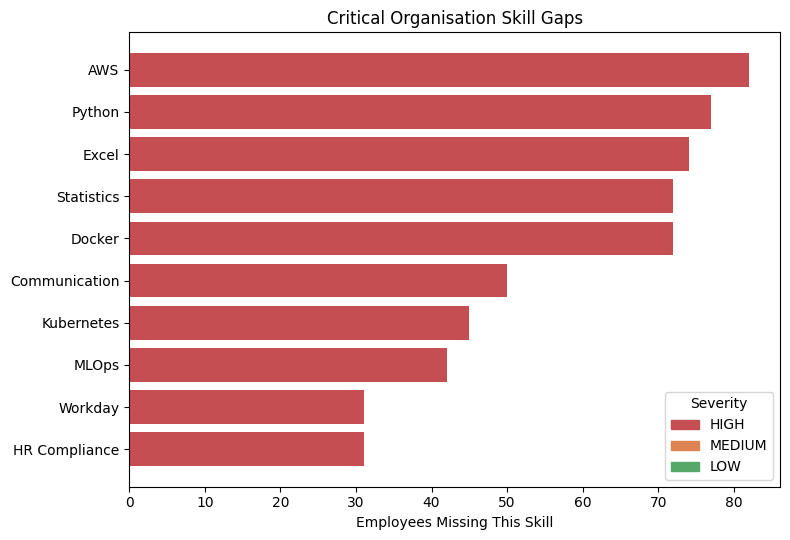

In [17]:
severity_colors = {"HIGH": "#C44E52", "MEDIUM": "#DD8452", "LOW": "#55A868"}

top10 = org_skill_gap.head(10).iloc[::-1]  # reverse so the biggest gap is on top of the barh chart
colors = top10["Severity"].map(severity_colors)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top10["Skill"], top10["MissingCount"], color=colors)
ax.set_xlabel("Employees Missing This Skill")
ax.set_title("Critical Organisation Skill Gaps")

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=s) for s, c in severity_colors.items()]
ax.legend(handles=legend_handles, title="Severity", loc="lower right")

plt.tight_layout()
plt.show()

---

## 15. Upskilling Recommendation Engine

### 15.1 Version 1 — Deliberately Dumb

Plain rules mapping a missing skill straight to a training recommendation. When an
employee has more than one gap, the recommendation targets the highest-importance
one first — no point recommending a *Medium* course while a *High* gap sits
unaddressed.

In [18]:
SKILL_TO_COURSE = {
    "MLOps": "Deploying and Monitoring Machine Learning Systems",
    "Docker": "Containerization Fundamentals with Docker",
    "Kubernetes": "Container Orchestration with Kubernetes",
    "AWS": "Cloud Infrastructure on AWS",
    "Cloud": "Cloud Computing Foundations",
    "Python": "Python for Data & ML Practitioners",
    "SQL": "Practical SQL for Analysts",
    "Statistics": "Applied Statistics for Business",
    "Machine Learning": "Machine Learning Foundations",
    "PyTorch": "Deep Learning with PyTorch",
    "Excel": "Advanced Excel for Business Analytics",
    "Tableau": "Data Visualization with Tableau",
    "Data Visualization": "Storytelling with Data Visualization",
    "Salesforce": "Salesforce Administration Essentials",
    "Workday": "Workday HCM Fundamentals",
    "Terraform": "Infrastructure as Code with Terraform",
    "CI/CD": "CI/CD Pipelines for Engineers",
    "Communication": "Effective Workplace Communication",
    "Negotiation": "Negotiation Skills for Sales Professionals",
    "CRM Tools": "CRM Best Practices",
    "HR Compliance": "HR Compliance Essentials",
    "Conflict Resolution": "Conflict Resolution in the Workplace",
    "Research Methods": "Research Methods & Experimental Design",
    "Java": "Java for Backend Engineers",
    "System Design": "System Design for Scalable Applications",
}

def recommend_v1(gap_skills, role, importance_lookup):
    """if \"MLOps\" in missing_skills: recommend(\"Learn MLOps\") -- generalized
    to pick the highest-importance gap when there's more than one."""
    if not gap_skills:
        return "No critical skill gaps -- keep up ongoing development"
    top_skill = max(
        gap_skills,
        key=lambda s: IMPORTANCE_WEIGHT.get(importance_lookup.get((role, s), "Medium"), 1),
    )
    course = SKILL_TO_COURSE.get(top_skill, f"Foundations of {top_skill}")
    return f'Learn {top_skill} -- "{course}"'


example_row = skill_gap_df.iloc[0]
print(recommend_v1(example_row["GapSkills"], example_row["JobRole"], skill_importance_lookup))

Learn Negotiation -- "Negotiation Skills for Sales Professionals"


### 15.2 Version 2 — Semantic Matching

The upgrade: instead of an exact-name lookup, compare the missing skill against a
course catalog by meaning, using cosine similarity — so a gap can match a course
whose title doesn't contain that exact word.

The project notes describe this using a downloaded sentence-transformer model.
This environment doesn't have network access to a model hub, so `TfidfVectorizer`
+ cosine similarity is used instead — real cosine-similarity matching, just on
keyword vectors rather than neural embeddings. It's a lighter-weight stand-in that
runs anywhere with no download; swapping in `sentence-transformers` later (once
network access allows it) is a one-line change to `vectorizer`/`course_vectors`,
everything downstream stays the same.

Each course gets a short description with related terms, not just its title — that
extra text is what lets a query like `"Generative AI"` (never seen as an exact
skill name) still land on a sensible course.

In [19]:
SKILL_COURSE_CATALOG = {
    "MLOps": ("Deploying and Monitoring Machine Learning Systems",
              "MLOps machine learning operations model deployment monitoring production pipelines for ML"),
    "Docker": ("Containerization Fundamentals with Docker",
               "Docker containers containerization building images Dockerfile"),
    "Kubernetes": ("Container Orchestration with Kubernetes",
                   "Kubernetes container orchestration clusters pods scaling deployments"),
    "AWS": ("Cloud Infrastructure on AWS",
            "AWS Amazon Web Services cloud infrastructure EC2 S3 cloud computing"),
    "Cloud": ("Cloud Computing Foundations",
              "cloud computing infrastructure AWS Azure GCP cloud platforms"),
    "Python": ("Python for Data & ML Practitioners",
               "Python programming data science scripting pandas numpy"),
    "SQL": ("Practical SQL for Analysts",
            "SQL databases queries relational data analysis"),
    "Statistics": ("Applied Statistics for Business",
                   "statistics statistical analysis hypothesis testing data science"),
    "Machine Learning": ("Machine Learning Foundations",
                         "machine learning models algorithms supervised unsupervised learning AI"),
    "PyTorch": ("Deep Learning with PyTorch",
                "PyTorch deep learning neural networks tensors"),
    "Excel": ("Advanced Excel for Business Analytics",
              "Excel spreadsheets formulas pivot tables business analytics"),
    "Tableau": ("Data Visualization with Tableau",
                "Tableau dashboards data visualization BI reporting"),
    "Data Visualization": ("Storytelling with Data Visualization",
                           "data visualization charts dashboards storytelling with data"),
    "Salesforce": ("Salesforce Administration Essentials",
                   "Salesforce CRM customer relationship management administration"),
    "Workday": ("Workday HCM Fundamentals",
                "Workday HCM human capital management HR systems"),
    "Terraform": ("Infrastructure as Code with Terraform",
                  "Terraform infrastructure as code IaC provisioning cloud resources"),
    "CI/CD": ("CI/CD Pipelines for Engineers",
              "continuous integration continuous deployment pipelines automation"),
    "Communication": ("Effective Workplace Communication",
                      "communication skills workplace collaboration presentations"),
    "Negotiation": ("Negotiation Skills for Sales Professionals",
                    "negotiation skills sales deals persuasion"),
    "CRM Tools": ("CRM Best Practices",
                  "CRM tools customer relationship management sales pipeline"),
    "HR Compliance": ("HR Compliance Essentials",
                      "HR compliance labor law regulations policy"),
    "Conflict Resolution": ("Conflict Resolution in the Workplace",
                            "conflict resolution mediation workplace disputes"),
    "Research Methods": ("Research Methods & Experimental Design",
                         "research methods experimental design methodology science"),
    "Java": ("Java for Backend Engineers",
             "Java programming backend software engineering"),
    "System Design": ("System Design for Scalable Applications",
                      "system design architecture scalability distributed systems"),
}

course_catalog = pd.DataFrame(
    [{"course_title": title, "description": desc} for title, desc in SKILL_COURSE_CATALOG.values()]
).drop_duplicates(subset="course_title").reset_index(drop=True)

vectorizer = TfidfVectorizer(stop_words="english")
course_vectors = vectorizer.fit_transform(course_catalog["description"])

def recommend_v2(missing_skill):
    query_vec = vectorizer.transform([missing_skill])
    similarities = cosine_similarity(query_vec, course_vectors)[0]
    best_idx = similarities.argmax()
    return course_catalog.iloc[best_idx]["course_title"], round(float(similarities[best_idx]), 3)

for query in ["MLOps", "Cloud", "Generative AI", "Docker"]:
    course, score = recommend_v2(query)
    print(f'{query!r:20} -> "{course}"  (similarity {score})')

'MLOps'              -> "Deploying and Monitoring Machine Learning Systems"  (similarity 0.333)
'Cloud'              -> "Cloud Computing Foundations"  (similarity 0.576)
'Generative AI'      -> "Machine Learning Foundations"  (similarity 0.345)
'Docker'             -> "Containerization Fundamentals with Docker"  (similarity 0.408)


---

## 16. Employee Intelligence Table

Everything from Day 2 and today lands here — **one row per employee** that pulls
together attrition risk, engagement, role, skill gaps, and the recommendation. This
table is the actual business output of the whole project so far; the eventual
dashboard is basically just a view onto it.

### 16.1 Attrition Risk, from the Day 2 Model

The same feature engineering from Day 2 (Section 5) is re-applied here to build the
model's input — a pipeline expects to see the same shape of data it was trained on,
so this step can't be skipped even though the raw columns look "ready".

In [20]:
df = attrition.merge(engagement, on="EmployeeID", how="left", validate="one_to_one")

df["IncomePerYear"] = df["MonthlyIncome"] * 12 / df["YearsAtCompany"].replace(0, 1)
df["PromotionGapRatio"] = df["YearsSinceLastPromotion"] / df["YearsAtCompany"].replace(0, 1)
df["OverallSatisfaction"] = (df["JobSatisfaction"] + df["WorkLifeBalance"]) / 2
df["ExperienceRatio"] = df["YearsAtCompany"] / (df["NumCompaniesWorked"] + 1)

categorical_cols = ["Department", "JobRole", "OverTime"]
numeric_cols = [c for c in df.columns if c not in categorical_cols + ["Attrition", "EmployeeID"]]
X_all = df[categorical_cols + numeric_cols]

df["Attrition_Prob"] = attrition_pipeline.predict_proba(X_all)[:, 1].round(4)

# Percentile-based buckets instead of fixed probability cutoffs.
# With this dataset's base rate skewed toward "Yes", a fixed 0.7/0.4 cutoff
# flags almost everyone HIGH -- percentiles keep the buckets meaningful
# regardless of how skewed the underlying population is.
#
# Top 20% of predicted risk -> HIGH, next 30% -> MEDIUM, bottom 50% -> LOW.
high_cutoff = df["Attrition_Prob"].quantile(0.80)
medium_cutoff = df["Attrition_Prob"].quantile(0.50)

def risk_bucket(prob):
    if prob >= high_cutoff:
        return "HIGH"
    if prob >= medium_cutoff:
        return "MEDIUM"
    return "LOW"

df["Risk"] = df["Attrition_Prob"].apply(risk_bucket)

print(f"HIGH cutoff:   Attrition_Prob >= {high_cutoff:.3f}")
print(f"MEDIUM cutoff: Attrition_Prob >= {medium_cutoff:.3f}")
df["Risk"].value_counts()

df["Risk"] = df["Attrition_Prob"].apply(risk_bucket)
df["Risk"].value_counts()

HIGH cutoff:   Attrition_Prob >= 0.945
MEDIUM cutoff: Attrition_Prob >= 0.883


Risk
LOW       300
MEDIUM    165
HIGH      135
Name: count, dtype: int64

### 16.2 Skill Gap + Recommendation, per Employee

Reusing the exact functions from Sections 13 and 15 — nothing new, just applying
them to build two more columns on the same table.

In [21]:
def build_intelligence_row(employee_id, role):
    required, has, gap, severity_score = compute_skill_gap(
        employee_id, role, role_required_map, employee_skill_map, skill_importance_lookup
    )
    recommendation = recommend_v1(sorted(gap), role, skill_importance_lookup)
    return pd.Series({
        "Skill_Gap": ", ".join(sorted(gap)) if gap else "(none)",
        "Gap_Severity": severity_score,
        "Recommendation": recommendation,
    })

gap_and_rec = df.apply(lambda row: build_intelligence_row(row["EmployeeID"], row["JobRole"]), axis=1)
df = pd.concat([df, gap_and_rec], axis=1)

df[["EmployeeID", "JobRole", "Skill_Gap", "Gap_Severity", "Recommendation"]].head()

,EmployeeID,JobRole,Skill_Gap,Gap_Severity,Recommendation
0,1,Sales Executive,"Communication, Excel, Negotiation",4,"Learn Negotiation -- ""Negotiation Skills for S..."
1,2,Research Scientist,(none),0,No critical skill gaps -- keep up ongoing deve...
2,3,Software Engineer,"Java, System Design",3,"Learn System Design -- ""System Design for Scal..."
3,4,Software Engineer,"AWS, Docker, Kubernetes, Python",6,"Learn Kubernetes -- ""Container Orchestration w..."
4,5,Software Engineer,"AWS, Docker, Kubernetes",4,"Learn Kubernetes -- ""Container Orchestration w..."


### 16.3 The Final Table

Matching the project notes' target shape (`Employee_ID | Dept | Attrition_Prob |
Risk | Engagement | Role | Skill_Gap | Recommendation`), with the severity score
kept alongside for sorting/filtering on the eventual dashboard.

In [22]:
employee_intelligence = df.rename(columns={
    "EmployeeID": "Employee_ID", "Department": "Dept",
    "EngagementScore": "Engagement", "JobRole": "Role",
})[[
    "Employee_ID", "Dept", "Attrition_Prob", "Risk", "Engagement",
    "Role", "Skill_Gap", "Gap_Severity", "Recommendation",
]]

employee_intelligence.head(10)

,Employee_ID,Dept,Attrition_Prob,Risk,Engagement,Role,Skill_Gap,Gap_Severity,Recommendation
0,1,IT,0.960,HIGH,81,Sales Executive,"Communication, Excel, Negotiation",4,"Learn Negotiation -- ""Negotiation Skills for S..."
1,2,IT,0.815,LOW,61,Research Scientist,(none),0,No critical skill gaps -- keep up ongoing deve...
2,3,IT,0.965,HIGH,60,Software Engineer,"Java, System Design",3,"Learn System Design -- ""System Design for Scal..."
3,4,Research & Development,0.940,MEDIUM,59,Software Engineer,"AWS, Docker, Kubernetes, Python",6,"Learn Kubernetes -- ""Container Orchestration w..."
4,5,IT,0.945,HIGH,67,Software Engineer,"AWS, Docker, Kubernetes",4,"Learn Kubernetes -- ""Container Orchestration w..."
5,6,IT,0.935,MEDIUM,52,Software Engineer,(none),0,No critical skill gaps -- keep up ongoing deve...
6,7,Research & Development,0.920,MEDIUM,76,Sales Executive,"CRM Tools, Salesforce",3,"Learn Salesforce -- ""Salesforce Administration..."
7,8,Human Resources,0.935,MEDIUM,81,Sales Executive,(none),0,No critical skill gaps -- keep up ongoing deve...
8,9,Sales,0.945,HIGH,79,ML Engineer,(none),0,No critical skill gaps -- keep up ongoing deve...
9,10,IT,0.095,LOW,83,Data Analyst,(none),0,No critical skill gaps -- keep up ongoing deve...


### 16.4 Highest-Priority Employees

The employees HR would actually want to see first: high attrition risk *and* a
meaningful skill gap sitting on top of that risk.

In [23]:
priority_view = (
    employee_intelligence[employee_intelligence["Risk"] == "HIGH"]
    .sort_values(["Gap_Severity", "Attrition_Prob"], ascending=False)
    .head(15)
    .reset_index(drop=True)
)
priority_view

,Employee_ID,Dept,Attrition_Prob,Risk,Engagement,Role,Skill_Gap,Gap_Severity,Recommendation
0,563,Research & Development,0.980,HIGH,62,MLOps Engineer,"AWS, CI/CD, Cloud, Docker, Kubernetes, MLOps, ...",10,"Learn Docker -- ""Containerization Fundamentals..."
1,398,IT,0.950,HIGH,64,Software Engineer,"AWS, Java, Kubernetes, Python, System Design",8,"Learn Kubernetes -- ""Container Orchestration w..."
2,210,Human Resources,0.970,HIGH,60,ML Engineer,"AWS, Docker, MLOps, Machine Learning, Statistics",7,"Learn Docker -- ""Containerization Fundamentals..."
3,377,Research & Development,0.945,HIGH,91,MLOps Engineer,"AWS, Docker, Kubernetes, MLOps",7,"Learn Docker -- ""Containerization Fundamentals..."
4,402,Human Resources,0.965,HIGH,53,Software Engineer,"AWS, Docker, Kubernetes, Python",6,"Learn Kubernetes -- ""Container Orchestration w..."
5,469,Human Resources,0.960,HIGH,58,Software Engineer,"AWS, Docker, Kubernetes, System Design",6,"Learn Kubernetes -- ""Container Orchestration w..."
6,527,Human Resources,0.995,HIGH,84,Software Engineer,"Java, Python, System Design",5,"Learn Python -- ""Python for Data & ML Practiti..."
7,173,Sales,0.990,HIGH,73,HR Executive,"Communication, Conflict Resolution, HR Complia...",5,"Learn Workday -- ""Workday HCM Fundamentals"""
8,284,Research & Development,0.985,HIGH,89,MLOps Engineer,"CI/CD, Cloud, MLOps, Terraform",5,"Learn MLOps -- ""Deploying and Monitoring Machi..."
9,184,Human Resources,0.975,HIGH,79,Software Engineer,"Docker, Kubernetes, Python",5,"Learn Kubernetes -- ""Container Orchestration w..."


### 16.5 Saving the Employee Intelligence Table

The output of today, saved for Day 4's API/dashboard to read directly instead of
recomputing all of this from scratch.

In [24]:
employee_intelligence.to_csv(f"{PROCESSED_PATH}/employee_intelligence.csv", index=False)
print(f"Saved {len(employee_intelligence)} rows to {PROCESSED_PATH}/employee_intelligence.csv")

Saved 600 rows to ./data/processed/employee_intelligence.csv


---

## End of Day 3 — Summary

What's in hand at the end of today, per the project checklist.

In [25]:
print("DAY 3 COMPLETE\n" + "="*60)

print(f"\n10. Engagement Analytics -- company avg {overall_avg_engagement:.1f}, "
      f"lowest department: {engagement_by_dept.index[0]} ({engagement_by_dept.iloc[0]:.1f})")

print(f"\n11. Role Intelligence -- {len(role_master)} roles mapped, "
      f"{len(required_skills)} (role, skill) requirements combined into one table")

print(f"\n12. Employee Skills -- synthetic table built ({len(employee_skills)} rows), "
      f"saved to {EXTERNAL_PATH}/employee_skills.csv")

print(f"\n13. Skill Gap Engine -- gap computed for all {len(skill_gap_df)} employees "
      f"(avg gap: {skill_gap_df['GapCount'].mean():.1f} skills)")

print(f"\n14. Organization-Wide Skill Gap -- {len(org_skill_gap)} distinct skills tracked, "
      f"{(org_skill_gap['Severity'] == 'HIGH').sum()} at HIGH severity")
print("   Top 3 critical gaps:")
for _, row in org_skill_gap.head(3).iterrows():
    print(f"     - {row['Skill']}: {row['MissingCount']} employees missing ({row['Severity']})")

print(f"\n15. Recommendation Engine -- V1 rule-based + V2 TF-IDF semantic matching, both working")

print(f"\n16. Employee Intelligence Table -- {len(employee_intelligence)} rows, "
      f"{(employee_intelligence['Risk'] == 'HIGH').sum()} employees at HIGH attrition risk")
print(f"   Saved to: {PROCESSED_PATH}/employee_intelligence.csv")

print("\nReady for Day 4 (Application) -- this table is what the FastAPI backend")
print("and Streamlit dashboard will be built on top of.")

DAY 3 COMPLETE

10. Engagement Analytics -- company avg 68.8, lowest department: Human Resources (68.1)

11. Role Intelligence -- 7 roles mapped, 44 (role, skill) requirements combined into one table

12. Employee Skills -- synthetic table built (2469 rows), saved to ./data/external/employee_skills.csv

13. Skill Gap Engine -- gap computed for all 600 employees (avg gap: 1.5 skills)

14. Organization-Wide Skill Gap -- 25 distinct skills tracked, 16 at HIGH severity
   Top 3 critical gaps:
     - AWS: 82 employees missing (HIGH)
     - Python: 77 employees missing (HIGH)
     - Excel: 74 employees missing (HIGH)

15. Recommendation Engine -- V1 rule-based + V2 TF-IDF semantic matching, both working

16. Employee Intelligence Table -- 600 rows, 135 employees at HIGH attrition risk
   Saved to: ./data/processed/employee_intelligence.csv

Ready for Day 4 (Application) -- this table is what the FastAPI backend
and Streamlit dashboard will be built on top of.


In [26]:
## 16.5 Career Path Simulation

# Progression map: current role -> next logical role. Roles with no defined
# next step (e.g. Sales Executive, HR Executive) are left out on purpose --
# they're lateral roles in this dataset, not a ladder rung.
CAREER_PATHS = {
    "Data Analyst": "Research Scientist",
    "Research Scientist": "ML Engineer",
    "Software Engineer": "ML Engineer",
    "ML Engineer": "MLOps Engineer",
}

TRAINING_EFFECTIVENESS = 0.85  # assumed % of a gap skill closed by completing its course

def simulate_career_path(employee_id, current_role):
    target_role = CAREER_PATHS.get(current_role)
    if target_role is None:
        return None  # no defined next step for this role

    required = role_required_map.get(target_role, set())
    has = employee_skill_map.get(employee_id, set())
    if not required:
        return None

    matched = has & required
    gap = required - has
    weight = 100 / len(required)

    readiness_today = round(len(matched) * weight, 1)
    readiness_after = round(min(100, readiness_today + len(gap) * weight * TRAINING_EFFECTIVENESS), 1)

    return {
        "EmployeeID": employee_id,
        "CurrentRole": current_role,
        "TargetRole": target_role,
        "MatchedSkills": sorted(matched),
        "MissingSkills": sorted(gap),
        "ReadinessToday": readiness_today,
        "ReadinessAfterTraining": readiness_after,
    }


career_rows = []
for _, emp in attrition.iterrows():
    result = simulate_career_path(emp["EmployeeID"], emp["JobRole"])
    if result:
        career_rows.append(result)

career_path_df = pd.DataFrame(career_rows)
career_path_df.to_csv(f"{PROCESSED_PATH}/career_path_intelligence.csv", index=False)

print(f"Career path simulated for {len(career_path_df)} employees "
      f"(roles with no next step excluded)")
print(f"Avg readiness today: {career_path_df['ReadinessToday'].mean():.1f}%  |  "
      f"Avg after training: {career_path_df['ReadinessAfterTraining'].mean():.1f}%")
career_path_df.sort_values("ReadinessToday", ascending=False).head(10)

Career path simulated for 340 employees (roles with no next step excluded)
Avg readiness today: 26.9%  |  Avg after training: 89.1%


,EmployeeID,CurrentRole,TargetRole,MatchedSkills,MissingSkills,ReadinessToday,ReadinessAfterTraining
338,596,Research Scientist,ML Engineer,"[AWS, Python, Statistics]","[Docker, MLOps, Machine Learning, PyTorch]",42.9,91.5
0,2,Research Scientist,ML Engineer,"[AWS, Python, Statistics]","[Docker, MLOps, Machine Learning, PyTorch]",42.9,91.5
1,3,Software Engineer,ML Engineer,"[AWS, Docker, Python]","[MLOps, Machine Learning, PyTorch, Statistics]",42.9,91.5
322,568,Software Engineer,ML Engineer,"[AWS, Docker, Python]","[MLOps, Machine Learning, PyTorch, Statistics]",42.9,91.5
321,567,ML Engineer,MLOps Engineer,"[AWS, Docker, MLOps]","[CI/CD, Cloud, Kubernetes, Terraform]",42.9,91.5
320,566,ML Engineer,MLOps Engineer,"[AWS, Docker, MLOps]","[CI/CD, Cloud, Kubernetes, Terraform]",42.9,91.5
316,558,Software Engineer,ML Engineer,"[AWS, Docker, Python]","[MLOps, Machine Learning, PyTorch, Statistics]",42.9,91.5
313,548,Software Engineer,ML Engineer,"[AWS, Docker, Python]","[MLOps, Machine Learning, PyTorch, Statistics]",42.9,91.5
32,56,ML Engineer,MLOps Engineer,"[AWS, Docker, MLOps]","[CI/CD, Cloud, Kubernetes, Terraform]",42.9,91.5
31,55,Software Engineer,ML Engineer,"[AWS, Docker, Python]","[MLOps, Machine Learning, PyTorch, Statistics]",42.9,91.5


In [27]:
## 16.6 Organization Skill Heatmap & Hire-vs-Reskill Recommendation

# Reuses org_skill_gap (Section 14) -- adds Available count and a
# reskill/hire split, mirroring the deck's Slide 13 logic:
# Gap -> Cost of Training -> Cost of Hiring -> Internal Availability -> Recommendation
RESKILL_CAPACITY_RATIO = 0.6  # assume 60% of a skill gap can realistically be closed via internal training

org_skill_heatmap = org_skill_gap.copy()
org_skill_heatmap["Available"] = org_skill_heatmap["EligibleEmployees"] - org_skill_heatmap["MissingCount"]
org_skill_heatmap["ReskillCount"] = (org_skill_heatmap["MissingCount"] * RESKILL_CAPACITY_RATIO).round().astype(int)
org_skill_heatmap["HireCount"] = org_skill_heatmap["MissingCount"] - org_skill_heatmap["ReskillCount"]

org_skill_heatmap = org_skill_heatmap.rename(columns={"EligibleEmployees": "Required"})[[
    "Skill", "Required", "Available", "MissingCount", "MissingPct",
    "Severity", "ReskillCount", "HireCount",
]]

org_skill_heatmap.to_csv(f"{PROCESSED_PATH}/org_skill_heatmap.csv", index=False)

print(f"Org skill heatmap saved ({len(org_skill_heatmap)} skills)")
print(f"Total recommended: reskill {org_skill_heatmap['ReskillCount'].sum()}, "
      f"hire {org_skill_heatmap['HireCount'].sum()}")
org_skill_heatmap.head(10)

Org skill heatmap saved (25 skills)
Total recommended: reskill 544, hire 366


,Skill,Required,Available,MissingCount,MissingPct,Severity,ReskillCount,HireCount
0,AWS,325,243,82,13.7,HIGH,49,33
1,Python,254,177,77,12.8,HIGH,46,31
2,Excel,275,201,74,12.3,HIGH,44,30
3,Statistics,257,185,72,12.0,HIGH,43,29
4,Docker,240,168,72,12.0,HIGH,43,29
5,Communication,189,139,50,8.3,HIGH,30,20
6,Kubernetes,154,109,45,7.5,HIGH,27,18
7,MLOps,157,115,42,7.0,HIGH,25,17
8,Workday,105,74,31,5.2,HIGH,19,12
9,HR Compliance,105,74,31,5.2,HIGH,19,12
